In [1]:
import torch
from d2l import torch as d2l

If the input has multiple channels e.g. RxGxB, then the kernel should have the same number of channels as the input.
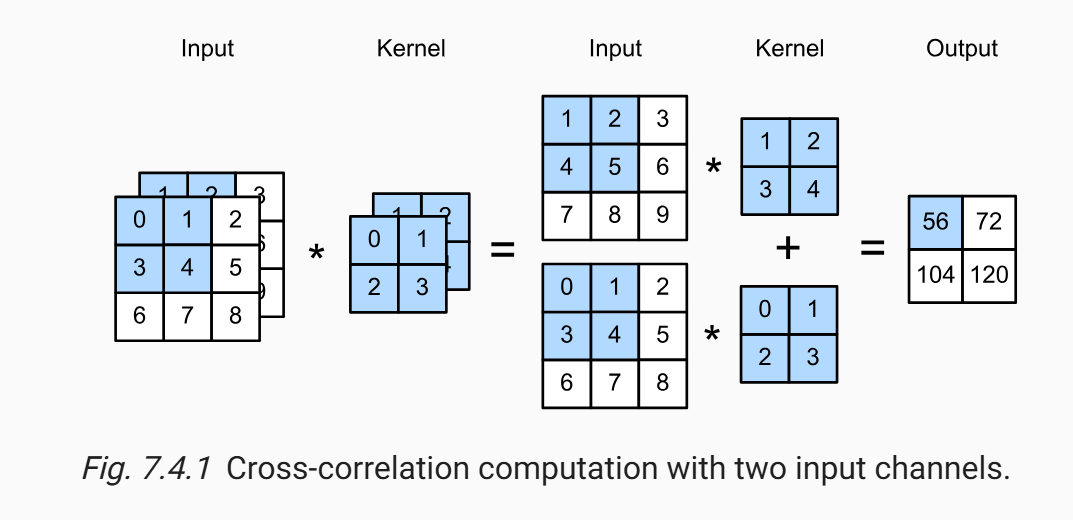

In [2]:
def conv2d(X, K): #@save
    """Compute the convolution for 2D matrices"""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

def conv2d_multi_channels(X, K):
    return sum(conv2d(x, k) for x, k in zip(X, K))

In [3]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
               [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

conv2d_multi_channels(X, K)

tensor([[ 56.,  72.],
        [104., 120.]])

In [4]:
# Multiple output channels - In addition to inputs, multiple channels are also create in each hidden layer of CNNs
# To get multiple output channels we stack o kernels of size i x h x w. So size of the output channels is o x i x h x w

def corr2d_multi_in_out(X, K):
    return torch.stack([conv2d_multi_channels(X, k) for k in K], 0)

In [5]:
K  = torch.stack((K, K+1, K+2), 0)
K.shape

torch.Size([3, 2, 2, 2])

In [6]:
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])